# **Lecture:** Pose Estimation with YOLO

![pose_estimation](pose-estimation.png)


This lab will guide you step-by-step through using YOLO for human pose estimation.

You will learn:
- What pose estimation is
- How YOLO performs keypoint detection
- How to run inference on images and videos
- How to interpret results

### **Introduction:** YOLO Pose Estimation

**YOLO Pose Estimation** extends traditional object detection by not only identifying people in an image but also locating key body joints (keypoints) such as the head, shoulders, elbows, and knees. Instead of predicting only bounding boxes, the model outputs a structured representation of the human body as a skeleton.

### **How It Works**

YOLO Pose models follow a single-stage pipeline:
1. The image is processed by a convolutional neural network.
2. The model detects people (bounding boxes).
3. For each detected person, it predicts a fixed set of keypoints (e.g., 17 joints).
4. Each keypoint includes:
   - **(x, y)** pixel coordinates  
   - **confidence score**

This allows real-time performance, making it suitable for applications such as human-computer interaction, sports analysis, and surveillance.

### **Training Dataset**

Most YOLO Pose models are trained on the **COCO Keypoints dataset** (Common Objects in Context), which includes:
- Over 200,000 labeled images
- 17 human body keypoints per person
- Diverse real-world scenarios (different poses, occlusions, lighting conditions)

The dataset defines a standard skeleton structure used across many pose estimation models.

### **YOLO Pose vs YOLO Object Detection**

| Feature | YOLO Object Detection | YOLO Pose Estimation |
|--------|----------------------|---------------------|
| Output | Bounding boxes + class labels | Bounding boxes + keypoints |
| Goal | Detect objects (person, car, etc.) | Understand human body structure |
| Detail level | Object-level | Fine-grained (joint-level) |
| Use cases | Counting, tracking, detection | Activity recognition, gesture analysis |

### **Why Pose Estimation Matters**

Unlike standard object detection, pose estimation provides semantic information about **how a person is moving or positioned**, enabling higher-level tasks such as:

- **Activity recognition**  
  *Example:* Detecting if a person is *raising their hand*, *sitting*, *walking*, or *squatting* based on joint positions and angles.

- **Gesture control**  
  *Example:* Using hand or arm movements to control a system, such as raising a hand to trigger an event or moving arms to interact with a game or presentation.

- **Biomechanical analysis**  
  *Example:* Measuring joint angles during exercises (e.g., squat depth, elbow angle in a bicep curl) to evaluate posture and prevent injuries.

- **Behavior understanding**  
  *Example:* Identifying patterns like *fall detection*, or *unusual movement* in surveillance scenarios.

___

### **Step 1:** Install Dependencies

We install the Ultralytics library, which provides YOLO.

In [2]:
%pip install --upgrade pip setuptools wheel
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install matplotlib
#%pip install numpy==1.26.4 --force-reinstall

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### **Step 2:** Import Libraries

We load the necessary Python libraries.

In [3]:
# Import YOLO from Ultralytics
from ultralytics import YOLO  # Main class to load and run the model

# Import OpenCV for image visualization
import cv2  # Used to read and display images

# Import matplotlib for plotting
import matplotlib.pyplot as plt  # Used to display images in notebooks
import numpy as np  # Numerical operations
from collections import deque  # Temporal smoothing for webcam predictions


### **Step 3:** Load a Pretrained Pose Model

YOLOv8 provides pretrained pose estimation models.
We will use `yolo26n-pose.pt` (nano version: fast and lightweight).

In [4]:
# Load the pretrained YOLO pose model
model = YOLO('yolo26n-pose.pt')  # Loads a lightweight pose estimation model

## **Step 4:** Run Pose Estimation on an Image

We will:
1. Load an image
2. Run inference
3. Visualize keypoints

WARNING ⚠️ 'source' is missing. Using 'source=/home/ariel/Escritorio/proyectos/Computer_Vision/.venv/lib/python3.12/site-packages/ultralytics/assets'.


[ WARN:0@2.049] global loadsave.cpp:278 findDecoder imread_('/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/zuck_running.jpg'): can't open/read file: check file path/integrity



image 1/2 /home/ariel/Escritorio/proyectos/Computer_Vision/.venv/lib/python3.12/site-packages/ultralytics/assets/bus.jpg: 640x480 4 persons, 57.4ms
image 2/2 /home/ariel/Escritorio/proyectos/Computer_Vision/.venv/lib/python3.12/site-packages/ultralytics/assets/zidane.jpg: 384x640 2 persons, 65.9ms
Speed: 1.7ms preprocess, 61.7ms inference, 6.1ms postprocess per image at shape (1, 3, 384, 640)


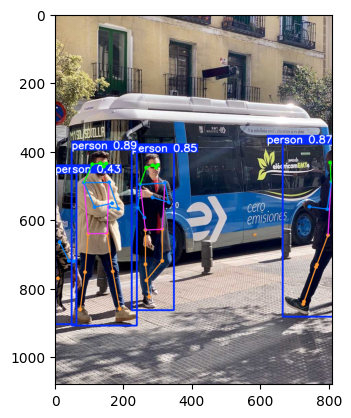

In [5]:
# Define image URL
#image = 'https://ultralytics.com/images/bus.jpg'  # Example image
image = cv2.imread('/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/zuck_running.jpg')  # Read image using OpenCV

# Run inference
results = model(image)  # Model processes the image and predicts keypoints

# Extract first result
result = results[0]  # YOLO returns a list, we take the first item

# Plot results
annotated_image = result.plot()  # Draws keypoints and skeleton on the image

# Convert BGR (OpenCV) to RGB for display
annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(annotated_image)  # Display image
#plt.axis('off')  # Hide axis

### **Step 5:** Understanding the Output

Each detected person has:
- Bounding box
- Keypoints (joints like elbows, knees, etc.)

You can access raw keypoints like this:

0  Nose  
1  Left eye  
2  Right eye  
3  Left ear  
4  Right ear  
5  Left shoulder  
6  Right shoulder  
7  Left elbow  
8  Right elbow  
9  Left wrist  
10 Right wrist  
11 Left hip  
12 Right hip  
13 Left knee  
14 Right knee  
15 Left ankle  
16 Right ankle  

![body_coco](body_coco.png)

In [6]:
# Access keypoints data
keypoints = result.keypoints  # Contains all detected keypoints

# Print keypoints shape
print(keypoints.xy.shape)  # Shows the shape of the keypoints array (num_people, num_keypoints (COCO format), 2 (each point has x and y))

# ---Print keypoints---
# conf: confidence values for each keypoint, one vector per person, 17 keypoints in COCO format
# data: raw coordinates and confidence values, one vector per person, 17 keypoints in COCO format, with x, y, and confidence for each keypoint
# xy: combined array of coordinates, one vector per person, 17 keypoints in COCO format
# xyn: normalized coordinates, one vector per person, 17 keypoints in COCO format, normalized to [0, 1]
print(keypoints)  # Displays coordinates and confidence values

torch.Size([4, 17, 2])
ultralytics.engine.results.Keypoints object with attributes:

conf: tensor([[0.9899, 0.9427, 0.9966, 0.1582, 0.9768, 0.9905, 0.9950, 0.9208, 0.9685, 0.8685, 0.9450, 0.9974, 0.9971, 0.9961, 0.9949, 0.9981, 0.9955],
        [0.2468, 0.2187, 0.0381, 0.2721, 0.0249, 0.7246, 0.0915, 0.9341, 0.0613, 0.9372, 0.2446, 0.5032, 0.1278, 0.9010, 0.3893, 0.8673, 0.4274],
        [0.9942, 0.9808, 0.9987, 0.2010, 0.9776, 0.9942, 0.9887, 0.9789, 0.7746, 0.9801, 0.7639, 0.9962, 0.9968, 0.9734, 0.9926, 0.9227, 0.9590],
        [0.0481, 0.0266, 0.0303, 0.0217, 0.0298, 0.1608, 0.0539, 0.4365, 0.1550, 0.5244, 0.3361, 0.0954, 0.0406, 0.2680, 0.1801, 0.2344, 0.1608]], device='cuda:0')
data: tensor([[[1.4232e+02, 4.4545e+02, 9.8987e-01],
         [1.4920e+02, 4.3676e+02, 9.4271e-01],
         [1.3253e+02, 4.3562e+02, 9.9657e-01],
         [1.5291e+02, 4.4183e+02, 1.5825e-01],
         [1.0870e+02, 4.3864e+02, 9.7681e-01],
         [1.5762e+02, 4.9133e+02, 9.9054e-01],
         [8.4110e+0

In [7]:
# Example: Accessing specific keypoint coordinates
keypoints.xy[0][5]  # (x, y) coordinates of left shoulder, first person, 6th keypoint (index 5)

tensor([157.6156, 491.3336], device='cuda:0')

In [8]:
# Example: Accessing specific keypoint data
keypoints.conf[0][5]  # confidence of left shoulder, first person, 6th keypoint (index 5)

tensor(0.9905, device='cuda:0')

### **Step 6:** Run Pose Estimation on Video

We can also process video streams frame-by-frame.

In [9]:
# Run inference on a video file and save results
video_path = '/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/jesper.mp4'  # Path to input video
output_path = '/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/jesper_annotated.mp4'  # Path to save annotated video
model(
    source=video_path,
    save=True,
    project='/Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation',
    name='jesper_annotated'
)  # Runs inference on video and saves annotated output 

FileNotFoundError: /Users/eugenio/Documents/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/jesper.mp4 does not exist

You have learned:
- How to use YOLO for pose estimation
- How to run inference on images and videos
- How to visualize and interpret keypoints

### **Individual Activity:**
- Propose an activity recognition task (e.g., wrist above head -> raising hand, knees bent -> sitting/squatting, etc.).
- Test the activity recognition task with your webcam.
- Present your work in class (5 pts.)
    - Clearly explain the selected activity and why it is relevant or useful (1 pt)
    - Identify and describe the specific code you implemented or modified -line by line- (2 pts)
    - Deliver a live webcam demonstration (pre-recorded videos will not be evaluated) (2 pts)

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>

## **Activity Solution:** Head Tilt Down Detection

### **Selected task**
Detect when the user's **head is tilted downward**.

### **Why this activity matters**
This activity can be used for:
- **fatigue awareness**
- **poor posture monitoring**
- **basic ergonomic feedback** during computer use

### **Keypoints used**
We will use the COCO body keypoints predicted by YOLO Pose:
- `0` → nose
- `5` → left shoulder
- `6` → right shoulder

### **Detection idea**
1. Compute the **midpoint between both shoulders**.
2. Measure the **vertical distance** from the nose to the shoulder line.
3. Normalize that distance by the **shoulder width**.
4. If the normalized distance becomes too small, the head is considered **tilted downward**.

This is a rule-based activity recognition layer built **on top of the pose estimation model**.

### **Code for the activity recognition rule**
The next cell implements the rule for detecting head tilt down.

In [10]:
# -----------------------------
# Parameters
# -----------------------------
CONF_THR = 0.40
HEAD_DOWN_RATIO_THR = 0.58
FRAMES_REQUIRED = 8

history = deque(maxlen=FRAMES_REQUIRED)


def get_keypoint(person_keypoints, idx):
    x = float(person_keypoints[idx][0])
    y = float(person_keypoints[idx][1])
    c = float(person_keypoints[idx][2])
    return x, y, c


def detect_head_tilt_down(person_keypoints, conf_thr=CONF_THR, ratio_thr=HEAD_DOWN_RATIO_THR):
    NOSE = 0
    LEFT_SHOULDER = 5
    RIGHT_SHOULDER = 6

    nose_x, nose_y, nose_conf = get_keypoint(person_keypoints, NOSE)
    ls_x, ls_y, ls_conf = get_keypoint(person_keypoints, LEFT_SHOULDER)
    rs_x, rs_y, rs_conf = get_keypoint(person_keypoints, RIGHT_SHOULDER)

    # Validate confidence
    if nose_conf < conf_thr or ls_conf < conf_thr or rs_conf < conf_thr:
        return False, None, None, None

    # Midpoint of shoulders
    shoulder_mid_x = (ls_x + rs_x) / 2.0
    shoulder_mid_y = (ls_y + rs_y) / 2.0

    # Shoulder width used for normalization
    shoulder_width = abs(rs_x - ls_x)

    if shoulder_width < 20:
        return False, None, None, None

    # Normalized vertical distance from nose to shoulder line
    neck_ratio = (shoulder_mid_y - nose_y) / shoulder_width

    # Smaller ratio means the head is lower
    head_down = neck_ratio < ratio_thr

    return head_down, neck_ratio, (int(shoulder_mid_x), int(shoulder_mid_y)), (int(nose_x), int(nose_y))

In [13]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Webcam could not be opened.")
else:
    print("Press 'q' to quit the webcam demo.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Frame could not be read.")
            break

        result = model(frame, verbose=False)[0]
        annotated_frame = result.plot()

        status_text = "No person detected"
        ratio_text = ""

        if result.keypoints is not None and result.keypoints.data is not None:
            keypoint_data = result.keypoints.data.cpu().numpy()

            if len(keypoint_data) > 0:
                # Select the person with the highest average keypoint confidence
                best_person = max(keypoint_data, key=lambda p: np.mean(p[:, 2]))

                detected, neck_ratio, shoulder_mid, nose_point = detect_head_tilt_down(best_person)

                history.append(1 if detected else 0)
                stable_detected = sum(history) >= int(0.7 * FRAMES_REQUIRED)

                if stable_detected:
                    status_text = "HEAD DOWN DETECTED"
                else:
                    status_text = "HEAD UP / NEUTRAL"

                if neck_ratio is not None:
                    ratio_text = f"ratio: {neck_ratio:.2f}"

                if shoulder_mid is not None and nose_point is not None:
                    cv2.line(annotated_frame, nose_point, shoulder_mid, (255, 255, 0), 2)
                    cv2.circle(annotated_frame, nose_point, 5, (0, 255, 255), -1)
                    cv2.circle(annotated_frame, shoulder_mid, 5, (255, 0, 255), -1)
            else:
                history.clear()
        else:
            history.clear()

        cv2.putText(
            annotated_frame,
            status_text,
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255) if "DOWN" in status_text else (0, 255, 0),
            2
        )

        if ratio_text:
            cv2.putText(
                annotated_frame,
                ratio_text,
                (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 255, 0),
                2
            )

        cv2.imshow("Head Tilt Down Detection", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

Press 'q' to quit the webcam demo.
